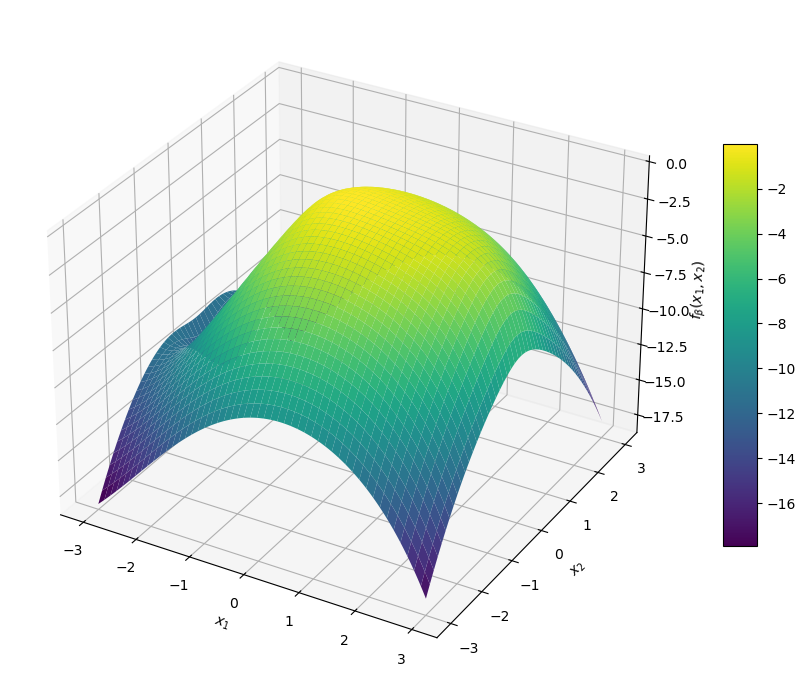

In [1]:
# =============================================================================
# Figure 2 (panel a): Target function surface plot
#
# Plots the three-dimensional surface of the target function
#
#   f_beta(x1, x2) = -(x1^2 + x2^2) * exp(-x1 * cos(beta*x1) / (1 + x2^2))
#
# with beta = 0.5 on the domain [-3, 3]^2, evaluated on a 200x200 grid.
# The function combines radial decay with an oscillatory x1-dependent term,
# producing a structured, non-trivial signal used in the MDL transition
# experiment of Section 3.
#
# Output: displayed interactively (save manually or extend with savefig).
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Target function
# ============================================================

def f_beta(x1, x2, beta):
    return -(x1**2+x2**2)*np.exp(-x1*np.cos(beta*x1)/(1+x2**2))

# Parameters
beta = 0.5
x1_min, x1_max = -3, 3
x2_min, x2_max = -3, 3
n = 200

# Grid
x1 = np.linspace(x1_min, x1_max, n)
x2 = np.linspace(x2_min, x2_max, n)
X1, X2 = np.meshgrid(x1, x2)

# Function values
Z = f_beta(X1, X2, beta)

# 3D plot
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(X1, X2, Z, cmap="viridis", linewidth=0, antialiased=True)

#ax.set_title(r"$f_\beta(x_1,x_2)=x_2 e^{x_1\cos(\beta x_2)}$")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_zlabel(r"$f_\beta(x_1,x_2)$")

fig.colorbar(surface, ax=ax, shrink=0.6, aspect=12)
plt.tight_layout()
plt.show()

Building Legendre spectral design...
  Number of spectral basis terms: 66
  Train size: 200
  Test size:  800

Running noise sweep...
[██████████████████████████████]  800/ 800 100.0% | elapsed  131.4s | ETA    0.0s


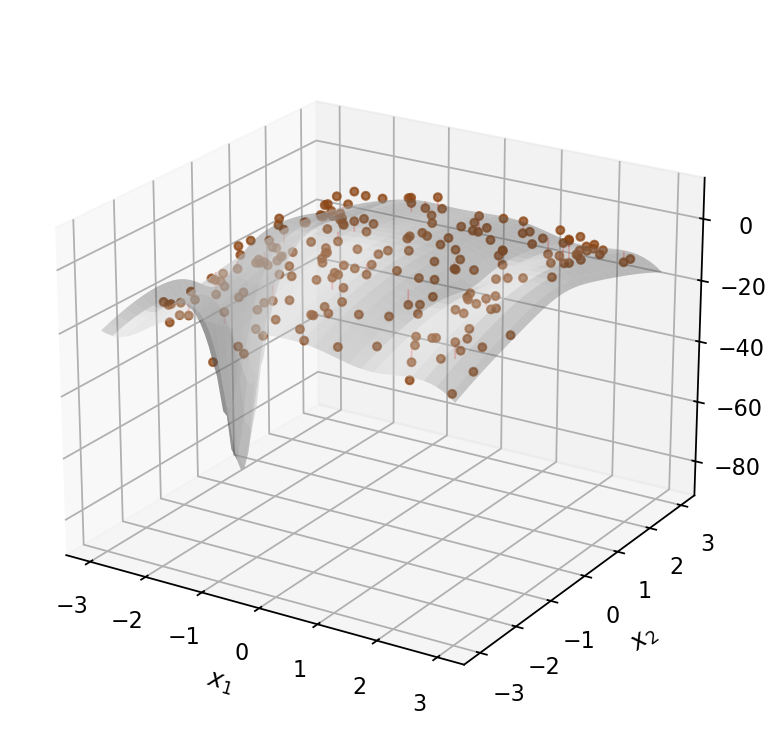

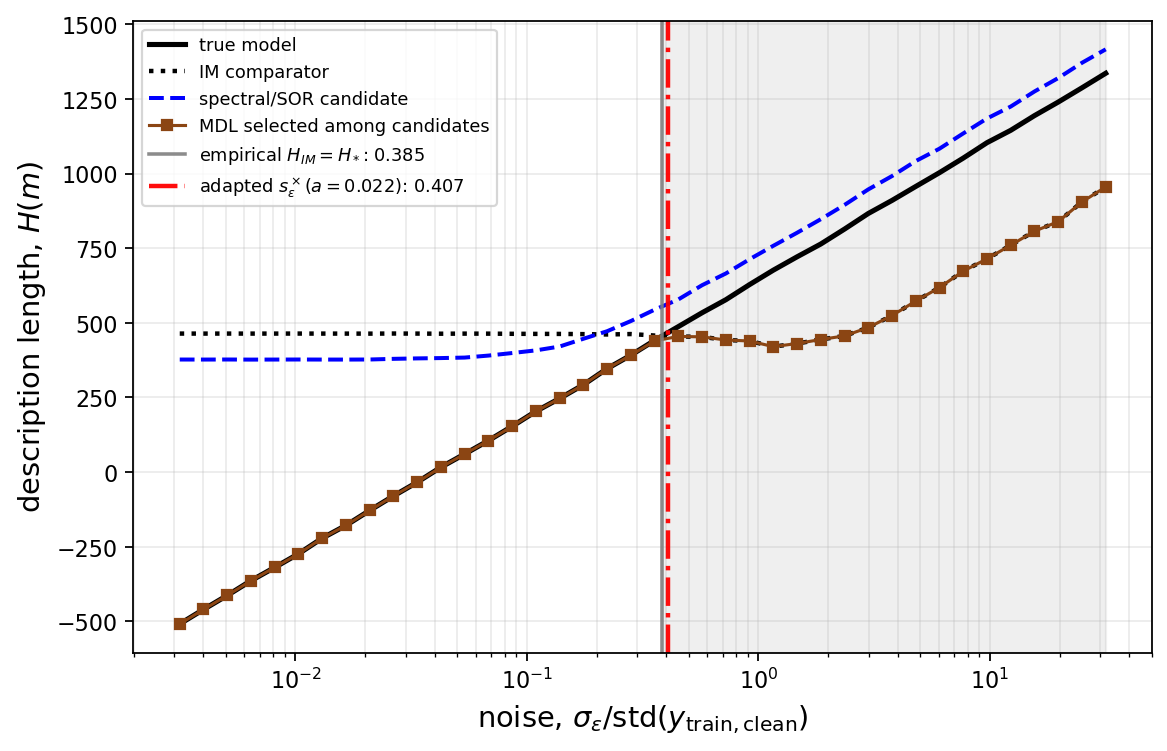

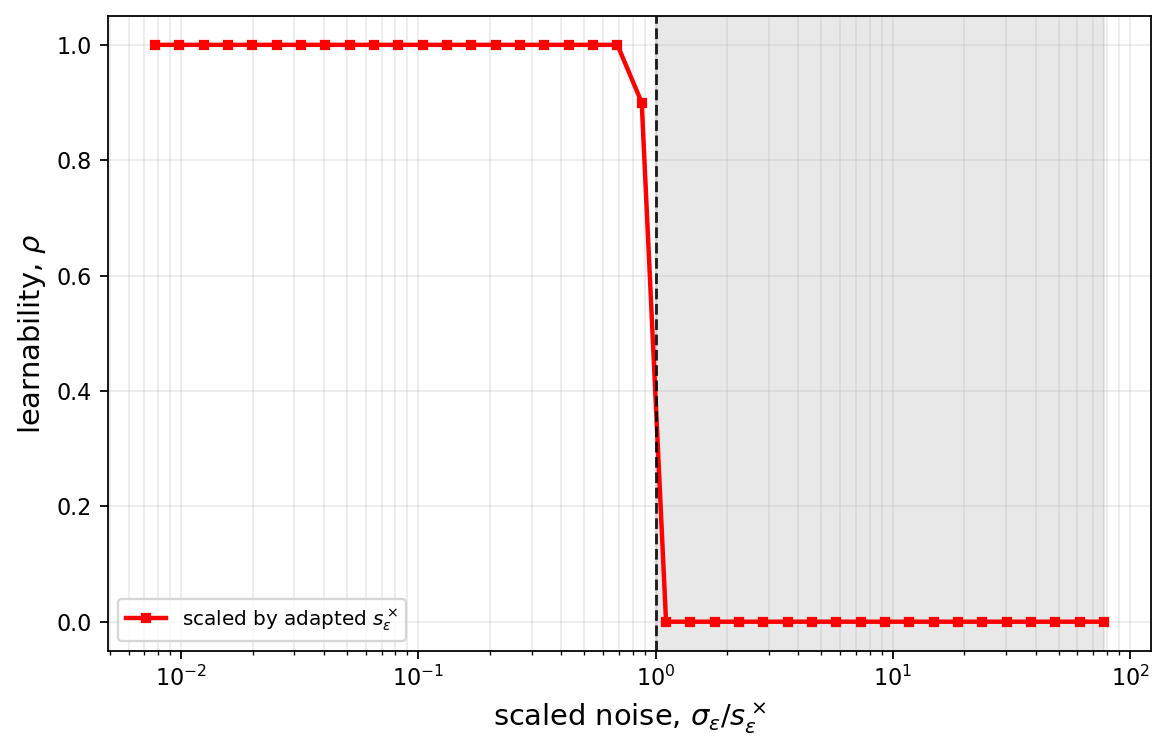

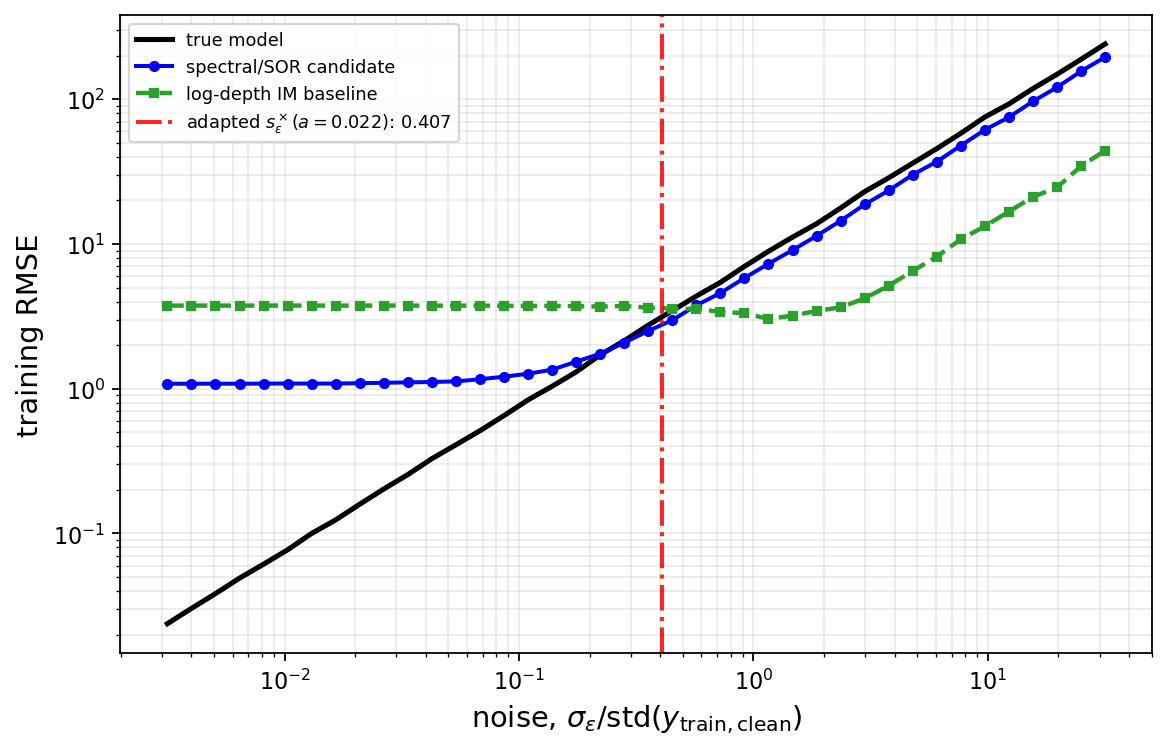

Saved figures and data to:
 - figs\01_model_and_noisy_data.[png/pdf]
 - figs\02_training_mdl_transition.[png/pdf]
 - figs\03_scaled_learnability_transition.[png/pdf]
 - figs\04_training_rmse_threshold.[png/pdf]
 - figs\mdl_transition_raw_results.csv
 - figs\mdl_transition_results.csv


,noise_level,sigma_mean,k_sor_mean,k_ols_mean,n_im_mean,delta2_im_clean_mean,delta2_im_clean_std,noise_x_reference_mean,noise_x_reference_std,sigma_x_reference_mean,...,H_train_sor_mean,H_train_sor_std,H_train_ols_mean,H_train_ols_std,H_train_im_mean,H_train_im_std,H_mdl_selected_mean,H_mdl_selected_std,is_true_mdl_mean,is_true_mdl_std
0,0.003162,0.024064,66.00,66.0,5.0,14.059658,0.0,0.705408,0.0,5.368051,...,377.103688,0.267535,377.094145,0.267564,464.019129,0.087581,-508.360726,10.089554,1.0,0.0
1,0.004005,0.030475,66.00,66.0,5.0,14.059658,0.0,0.705408,0.0,5.368051,...,376.996364,0.425324,376.986809,0.425369,463.972797,0.093933,-459.922680,10.238192,1.0,0.0
2,0.005071,0.038593,66.00,66.0,5.0,14.059658,0.0,0.705408,0.0,5.368051,...,377.182284,0.479975,377.172747,0.480024,464.012033,0.139151,-412.950438,12.175766,1.0,0.0
3,0.006422,0.048873,65.90,66.0,5.0,14.059658,0.0,0.705408,0.0,5.368051,...,376.868800,1.029352,377.124171,0.603558,463.963906,0.165285,-363.545543,10.836951,1.0,0.0
4,0.008133,0.061892,65.85,66.0,5.0,14.059658,0.0,0.705408,0.0,5.368051,...,377.014816,1.310358,377.402389,0.883483,463.994160,0.167963,-319.110581,9.490692,1.0,0.0


In [2]:
# =============================================================================
# MDL Transition Experiment: Spectral/SOR Candidate vs Log-Depth IM Baseline
#
# Implements the noise-threshold experiment of Section 3 (Generalized
# Learnability Threshold). For a two-dimensional target function
#
#   f_beta(x1, x2) = -(x1^2 + x2^2) * exp(-x1 * cos(beta*x1) / (1 + x2^2))
#
# the experiment compares three models under the MDL/BIC criterion as
# observation noise is swept over three decades:
#
#   True model         -- the noiseless signal, complexity k_true_proxy = 20
#   Spectral/SOR       -- sparse Legendre regression (Lasso), k = nnz(coef)
#   IM baseline        -- iterated-means at log-depth n_b = ceil(ln(k_sor + 1))
#
# At each noise level and over n_reps realisations, description lengths H(m)
# are computed and the MDL-preferred model is recorded. The empirical crossing
# H_IM = H_true is located and compared against the adaptive threshold formula
# (eq. 4 in the paper), with the noise-absorption parameter a estimated from
# the high-noise tail of the IM residual variance.
#
# The key quantity connecting theory to experiment is delta2_im_clean: the
# approximation error of the IM baseline evaluated on the noiseless signal,
# which enters the threshold formula as <delta_n^2>. This is computed once
# per depth and cached.
#
# Produces four output figures (PNG and PDF):
#   01_model_and_noisy_data        -- target surface and training observations
#   02_training_mdl_transition     -- H(m) vs noise with empirical and
#                                     predicted crossings (Figure 2b in paper)
#   03_scaled_learnability_transition -- rho vs sigma/sigma_x (Figure 2c)
#   04_training_rmse_threshold     -- training RMSE diagnostic (Figure 2d)
#
# Dependencies: numpy, pandas, matplotlib, scikit-learn
# =============================================================================

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.exceptions import ConvergenceWarning


# ============================================================
# Config
# ============================================================

CONFIG = {
    # Data
    "a": -3.0,
    "b": 3.0,
    "N_total": 1000,
    "train_frac": 0.2,
    "seed": 0,

    # True function complexity
    "beta": 2.5,

    # Noise sweep
    # noise std = noise_level * std(y_train_clean)
    "noise_grid": np.logspace(-2.5, 1.5, 40),
    "n_reps": 20,

    # Spectral / SOR model
    "d_max": 10,
    "lasso_alpha": 1e-4,

    # Effective true-model complexity used in H(m) and thresholds.
    # Should be larger than n_IM for a finite threshold.
    "k_true_proxy": 20,

    # Iterated-means baseline
    # n_IM = ceil(log(k_spectral + 1))
    "im_log_base": np.e,

    # Description length priors
    # H(m) = N/2 * log(2*pi*MSE) + (k_eff+1)/2 * log(N) - log_prior
    "prior_true": 0.0,
    "prior_spectral": 0.0,
    "prior_im": 0.0,

    # Estimate adaptive noise absorption a from high-noise tail
    "a_estimation_quantile": 0.65,

    # Output
    "figdir": "figs",
}


# ============================================================
# Plot style
# ============================================================

COL_TRUE = "black"
COL_SOR = "blue"
COL_OLS = "tab:orange"
COL_IM = "tab:green"
COL_MDL = "saddlebrown"
COL_ADAPT = "red"
COL_EMP = "gray"

FIGSIZE = (7.4, 4.8)
DPI_SHOW = 160
DPI_SAVE = 600


def savefig_both(basepath):
    """
    Save both PNG and PDF.
    """
    plt.savefig(basepath + ".png", dpi=DPI_SAVE, bbox_inches="tight")
    plt.savefig(basepath + ".pdf", dpi=DPI_SAVE, bbox_inches="tight")


# ============================================================
# Progress bar
# ============================================================

def notebook_progress(done, total, t0, every=1, bar_width=30):
    if done % every != 0 and done != total:
        return

    elapsed = time.time() - t0
    rate = done / elapsed if elapsed > 1e-12 else 0.0
    eta = (total - done) / rate if rate > 1e-12 else np.inf

    frac = done / max(total, 1)
    filled = int(round(bar_width * frac))
    bar = "█" * filled + " " * (bar_width - filled)
    eta_str = f"{eta:6.1f}s" if np.isfinite(eta) else "  inf s"

    print(
        f"\r[{bar}] {done:4d}/{total:4d} "
        f"{100*frac:5.1f}% | elapsed {elapsed:6.1f}s | ETA {eta_str}",
        end="" if done < total else "\n",
        flush=True,
    )


# ============================================================
# Small utilities
# ============================================================

def rmse(yhat, y):
    return float(np.sqrt(np.mean((np.asarray(yhat) - np.asarray(y)) ** 2)))


def mse(yhat, y, eps=1e-300):
    value = np.mean((np.asarray(yhat) - np.asarray(y)) ** 2)
    return float(max(value, eps))


def description_length_from_mse(
    mse_value,
    N_eval,
    N_penalty,
    k_eff,
    log_prior=0.0,
    eps=1e-300,
):
    """
    BIC/MDL-style description length:

        H(m) = N_eval/2 * log(2*pi*s_y^2(m))
             + (k_eff+1)/2 * log(N_penalty)
             - log p(m)
    """
    s2 = max(float(mse_value), eps)
    return (
        0.5 * N_eval * np.log(2.0 * np.pi * s2)
        + 0.5 * (k_eff + 1) * np.log(N_penalty)
        - log_prior
    )


def threshold_general(
    delta2,
    N_train,
    k_true,
    k_comp,
    signal_scale,
    log_prior_true=0.0,
    log_prior_comp=0.0,
    noise_absorption=1.0,
    eps=1e-300,
):
    """
    General threshold from

        H_comp = H_true

    using

        true residual variance       = sigma^2
        comparator residual variance = a*sigma^2 + delta^2

    where a = noise_absorption.

    Equality gives:

        log(a + delta^2 / sigma^2)
        =
        [2 Delta_M + (k_true - k_comp) log N] / N

    so

        sigma^2 = delta^2 / (exp(A) - a).

    Returns normalized noise sigma / signal_scale.
    """
    delta2 = max(float(delta2), eps)
    signal_scale = max(float(signal_scale), eps)

    delta_M = float(log_prior_comp) - float(log_prior_true)

    A = (
        2.0 * delta_M
        + (float(k_true) - float(k_comp)) * np.log(float(N_train))
    ) / float(N_train)

    denom = np.exp(A) - float(noise_absorption)

    if A <= 0 or denom <= 0:
        return np.nan, np.nan, A

    sigma_abs = np.sqrt(delta2 / denom)
    noise_level_x = sigma_abs / signal_scale

    return float(noise_level_x), float(sigma_abs), float(A)


def effective_im_depth(k_spectral, base=np.e):
    k_spectral = max(int(k_spectral), 1)
    return max(1, int(np.ceil(np.log(k_spectral + 1) / np.log(base))))


def nnz(coef, tol=1e-12):
    coef = np.asarray(coef)
    return int(np.count_nonzero(np.abs(coef) > tol))


def find_crossing_x(x, y_a, y_b):
    """
    First approximate x where y_a crosses y_b, interpolated in log-x.
    """
    x = np.asarray(x)
    diff = np.asarray(y_a) - np.asarray(y_b)
    signs = np.sign(diff)

    for i in range(1, len(x)):
        if signs[i] == 0:
            return float(x[i])

        if signs[i - 1] == 0:
            return float(x[i - 1])

        if signs[i] != signs[i - 1]:
            lx0, lx1 = np.log(x[i - 1]), np.log(x[i])
            d0, d1 = diff[i - 1], diff[i]
            t = -d0 / (d1 - d0)
            return float(np.exp(lx0 + t * (lx1 - lx0)))

    return None


# ============================================================
# Legendre spectral design
# ============================================================

def multi_indices_exact(total_deg, n_vars):
    if n_vars == 1:
        yield (total_deg,)
        return

    def rec(prefix, remaining_deg, remaining_dims):
        if remaining_dims == 1:
            yield tuple(prefix + (remaining_deg,))
            return

        for a_ in range(remaining_deg + 1):
            yield from rec(prefix + (a_,), remaining_deg - a_, remaining_dims - 1)

    yield from rec((), total_deg, n_vars)


def multi_indices_upto(d_max, n_vars):
    idx = []
    for k in range(d_max + 1):
        idx.extend(list(multi_indices_exact(k, n_vars)))
    return idx


def map_to_minus1_1(x, a, b):
    x = np.asarray(x)
    return (2.0 * x - (a + b)) / (b - a)


def eval_1d_legendre(u, k):
    coeffs = np.zeros(k + 1)
    coeffs[-1] = 1.0
    return np.polynomial.legendre.legval(u, coeffs)


def build_tensor_legendre_design(X, d_max, a, b):
    X = np.asarray(X)
    N, n_vars = X.shape

    indexmulti = multi_indices_upto(d_max, n_vars)
    M = len(indexmulti)

    U = map_to_minus1_1(X, a, b)

    vals = []
    for j in range(n_vars):
        uj = U[:, j]
        vals_j = [eval_1d_legendre(uj, k) for k in range(d_max + 1)]
        vals.append(vals_j)

    Phi = np.ones((N, M), dtype=float)

    for s, alpha in enumerate(indexmulti):
        col = np.ones(N, dtype=float)
        for j, deg in enumerate(alpha):
            col *= vals[j][deg]
        Phi[:, s] = col

    return Phi, indexmulti


# ============================================================
# Spectral fitting
# ============================================================

def fit_spectral_models(Phi_train, y_train_noisy, lasso_alpha):
    """
    Dense OLS spectral model and sparse spectral/SOR model.

    Lasso is fit on RMS-normalized columns for numerical stability.
    Coefficients are mapped back to the original Legendre basis.
    """
    ols = LinearRegression(fit_intercept=False)
    ols.fit(Phi_train, y_train_noisy)

    col_scale = np.sqrt(np.mean(Phi_train ** 2, axis=0))
    col_scale[col_scale < 1e-12] = 1.0
    Phi_scaled = Phi_train / col_scale[None, :]

    sor_scaled = Lasso(
        alpha=lasso_alpha,
        fit_intercept=False,
        max_iter=1_000_000,
        tol=1e-5,
        selection="cyclic",
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        sor_scaled.fit(Phi_scaled, y_train_noisy)

    class ScaledLassoWrapper:
        def __init__(self, model, col_scale):
            self.model = model
            self.col_scale = col_scale
            self.coef_ = model.coef_ / col_scale
            self.intercept_ = 0.0

        def predict(self, Phi):
            return Phi @ self.coef_

    sor = ScaledLassoWrapper(sor_scaled, col_scale)

    return ols, sor


# ============================================================
# Iterated means
# ============================================================

def iterated_means_predictors(y_train, K, eps=1e-14):
    """
    Returns train predictions for depths 1..K, shape (K, N_train).

    Depth 1 is the mean-only predictor.
    Depth k > 1 adds k-1 signed mean-residual corrections.
    """
    y = np.asarray(y_train, dtype=float)
    N = y.shape[0]

    K = int(max(K, 1))
    yhat_by_k = np.empty((K, N), dtype=float)

    mu0 = y.mean()
    rho = y - mu0
    yhat = np.full(N, mu0, dtype=float)

    yhat_by_k[0] = yhat

    for k in range(1, K):
        s = np.sign(rho)
        s[s == 0] = 1.0

        mu_k = np.mean(np.abs(rho))

        yhat = yhat + mu_k * s
        rho = rho - mu_k * s

        yhat_by_k[k] = yhat

        if np.mean(rho * rho) < eps:
            yhat_by_k[k:] = yhat
            break

    return yhat_by_k


# ============================================================
# Main experiment
# ============================================================

def run_mdl_transition_experiment(config):
    os.makedirs(config["figdir"], exist_ok=True)

    rng = np.random.default_rng(config["seed"])

    a = config["a"]
    b = config["b"]
    N_total = config["N_total"]
    train_frac = config["train_frac"]
    beta = config["beta"]
    d_max = config["d_max"]

    # ------------------------------------------------------------
    # Fixed X and fixed train/test split
    # ------------------------------------------------------------
    x1 = rng.uniform(a, b, size=N_total)
    x2 = rng.uniform(a, b, size=N_total)
    X = np.column_stack([x1, x2])

    perm = rng.permutation(N_total)
    N_train = int(train_frac * N_total)

    train_idx = perm[:N_train]
    test_idx = perm[N_train:]

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_clean = f_beta(X[:, 0], X[:, 1], beta)
    y_train_clean = y_clean[train_idx]
    y_test_clean = y_clean[test_idx]

    y_signal_scale = np.std(y_train_clean)
    N_test = len(y_test_clean)

    # ------------------------------------------------------------
    # Fixed spectral dictionary
    # ------------------------------------------------------------
    print("Building Legendre spectral design...")
    Phi_all, indexmulti = build_tensor_legendre_design(X, d_max=d_max, a=a, b=b)
    Phi_train = Phi_all[train_idx]
    Phi_test = Phi_all[test_idx]

    print(f"  Number of spectral basis terms: {Phi_train.shape[1]}")
    print(f"  Train size: {N_train}")
    print(f"  Test size:  {N_test}")

    raw_rows = []

    noise_grid = np.asarray(config["noise_grid"], dtype=float)
    n_reps = int(config["n_reps"])

    total_jobs = len(noise_grid) * n_reps
    t0 = time.time()

    print("\nRunning noise sweep...")
    progress_every = max(1, total_jobs // 200)

    # Cache clean IM comparator by depth
    clean_im_cache = {}

    for ni, noise_level in enumerate(noise_grid):
        for rep in range(n_reps):
            job = ni * n_reps + rep + 1

            rng_rep = np.random.default_rng(config["seed"] + 10_000 * ni + rep)

            sigma = noise_level * y_signal_scale

            y_train_noisy = y_train_clean + rng_rep.normal(
                0.0,
                sigma,
                size=y_train_clean.shape,
            )

            # ----------------------------
            # Spectral/SOR candidate
            # ----------------------------
            ols, sor = fit_spectral_models(
                Phi_train=Phi_train,
                y_train_noisy=y_train_noisy,
                lasso_alpha=config["lasso_alpha"],
            )

            yhat_sor_train = sor.predict(Phi_train)
            yhat_ols_train = ols.predict(Phi_train)

            k_sor = max(1, nnz(sor.coef_))
            k_ols = Phi_train.shape[1]

            # ----------------------------
            # Log-depth IM baseline
            # ----------------------------
            n_im = effective_im_depth(k_sor, base=config["im_log_base"])

            yhat_train_by_depth = iterated_means_predictors(
                y_train_noisy,
                K=n_im,
            )
            yhat_im_train_final = yhat_train_by_depth[n_im - 1]

            # Clean IM discrepancy for analytic/adapted thresholds
            if n_im not in clean_im_cache:
                yhat_im_clean_by_depth = iterated_means_predictors(
                    y_train_clean,
                    K=n_im,
                )
                clean_im_cache[n_im] = yhat_im_clean_by_depth[n_im - 1]

            yhat_im_clean_final = clean_im_cache[n_im]
            delta2_im_clean = mse(yhat_im_clean_final, y_train_clean)

            # Reference threshold with a = 1 is still computed internally
            # for diagnostics/CSV, but it is not plotted anywhere.
            noise_x_reference, sigma_x_reference, A_reference = threshold_general(
                delta2=delta2_im_clean,
                N_train=N_train,
                k_true=int(config["k_true_proxy"]),
                k_comp=int(n_im),
                log_prior_true=config["prior_true"],
                log_prior_comp=config["prior_im"],
                signal_scale=y_signal_scale,
                noise_absorption=1.0,
            )

            # ====================================================
            # Training-set H(m)
            # ====================================================
            mse_train_true = mse(y_train_clean, y_train_noisy)
            mse_train_sor = mse(yhat_sor_train, y_train_noisy)
            mse_train_ols = mse(yhat_ols_train, y_train_noisy)
            mse_train_im = mse(yhat_im_train_final, y_train_noisy)

            k_true_proxy = int(config["k_true_proxy"])

            H_train_true = description_length_from_mse(
                mse_train_true,
                N_eval=N_train,
                N_penalty=N_train,
                k_eff=k_true_proxy,
                log_prior=config["prior_true"],
            )

            H_train_sor = description_length_from_mse(
                mse_train_sor,
                N_eval=N_train,
                N_penalty=N_train,
                k_eff=k_sor,
                log_prior=config["prior_spectral"],
            )

            H_train_ols = description_length_from_mse(
                mse_train_ols,
                N_eval=N_train,
                N_penalty=N_train,
                k_eff=k_ols,
                log_prior=config["prior_spectral"],
            )

            H_train_im = description_length_from_mse(
                mse_train_im,
                N_eval=N_train,
                N_penalty=N_train,
                k_eff=n_im,
                log_prior=config["prior_im"],
            )

            # Candidate set MDL among what this experiment actually compares.
            H_mdl_selected = min(H_train_true, H_train_sor, H_train_ols, H_train_im)

            # Learnability indicator:
            # true model is learnable if it is the MDL model among candidates.
            is_true_mdl = float(H_train_true <= min(H_train_sor, H_train_ols, H_train_im))

            raw_rows.append({
                "noise_level": noise_level,
                "sigma": sigma,
                "rep": rep,

                "k_sor": k_sor,
                "k_ols": k_ols,
                "n_im": n_im,

                "delta2_im_clean": delta2_im_clean,
                "noise_x_reference": noise_x_reference,
                "sigma_x_reference": sigma_x_reference,
                "A_reference": A_reference,

                # Train RMSE
                "rmse_train_true": np.sqrt(mse_train_true),
                "rmse_train_sor": np.sqrt(mse_train_sor),
                "rmse_train_ols": np.sqrt(mse_train_ols),
                "rmse_train_im": np.sqrt(mse_train_im),

                # Training-set H(m)
                "H_train_true": H_train_true,
                "H_train_sor": H_train_sor,
                "H_train_ols": H_train_ols,
                "H_train_im": H_train_im,
                "H_mdl_selected": H_mdl_selected,

                # Learnability
                "is_true_mdl": is_true_mdl,
            })

            notebook_progress(
                done=job,
                total=total_jobs,
                t0=t0,
                every=progress_every,
            )

    raw = pd.DataFrame(raw_rows)

    # ------------------------------------------------------------
    # Estimate adaptive noise absorption a for IM
    # ------------------------------------------------------------
    # Model:
    #   MSE_IM(sigma) ≈ delta2 + a*sigma^2
    #
    # Estimate a from the upper tail of noise levels.
    q = float(config["a_estimation_quantile"])
    noise_cut = raw["noise_level"].quantile(q)
    high = raw["noise_level"] >= noise_cut

    a_vals = (
        (raw.loc[high, "rmse_train_im"] ** 2 - raw.loc[high, "delta2_im_clean"])
        / (raw.loc[high, "sigma"] ** 2)
    )
    a_vals = a_vals.replace([np.inf, -np.inf], np.nan).dropna().values

    if len(a_vals) == 0:
        a_im = np.nan
    else:
        # Robust clipping: a should be nonnegative.
        a_im = float(np.nanmedian(a_vals))
        a_im = max(a_im, 0.0)

    # Compute adapted threshold using median depth and median clean discrepancy.
    N_train = len(y_train_clean)
    n_im_med = int(np.round(np.nanmedian(raw["n_im"])))
    delta2_med = float(np.nanmedian(raw["delta2_im_clean"]))

    _, _, A_med = threshold_general(
        delta2=delta2_med,
        N_train=N_train,
        k_true=int(config["k_true_proxy"]),
        k_comp=n_im_med,
        log_prior_true=config["prior_true"],
        log_prior_comp=config["prior_im"],
        signal_scale=y_signal_scale,
        noise_absorption=1.0,
    )

    # Keep a below exp(A), otherwise no finite adapted threshold.
    if np.isfinite(a_im):
        a_im = min(a_im, max(np.exp(A_med) - 1e-10, 0.0))

    noise_x_adapted, sigma_x_adapted, A_adapted = threshold_general(
        delta2=delta2_med,
        N_train=N_train,
        k_true=int(config["k_true_proxy"]),
        k_comp=n_im_med,
        log_prior_true=config["prior_true"],
        log_prior_comp=config["prior_im"],
        signal_scale=y_signal_scale,
        noise_absorption=a_im if np.isfinite(a_im) else np.nan,
    )

    # Add adapted constants to raw
    raw["a_im_estimated"] = a_im
    raw["noise_x_adapted"] = noise_x_adapted
    raw["sigma_x_adapted"] = sigma_x_adapted
    raw["A_adapted"] = A_adapted

    # ------------------------------------------------------------
    # Aggregate over repetitions
    # ------------------------------------------------------------
    agg_spec = {
        "sigma": "mean",
        "k_sor": "mean",
        "k_ols": "mean",
        "n_im": "mean",

        "delta2_im_clean": ["mean", "std"],
        "noise_x_reference": ["mean", "std"],
        "sigma_x_reference": ["mean", "std"],
        "a_im_estimated": "mean",
        "noise_x_adapted": "mean",
        "sigma_x_adapted": "mean",

        "rmse_train_true": ["mean", "std"],
        "rmse_train_sor": ["mean", "std"],
        "rmse_train_ols": ["mean", "std"],
        "rmse_train_im": ["mean", "std"],

        "H_train_true": ["mean", "std"],
        "H_train_sor": ["mean", "std"],
        "H_train_ols": ["mean", "std"],
        "H_train_im": ["mean", "std"],
        "H_mdl_selected": ["mean", "std"],

        "is_true_mdl": ["mean", "std"],
    }

    agg = raw.groupby("noise_level", as_index=False).agg(agg_spec)

    agg.columns = [
        c[0] if c[1] == "" else f"{c[0]}_{c[1]}"
        for c in agg.columns.to_flat_index()
    ]

    aux = {
        "X": X,
        "X_train": X_train,
        "X_test": X_test,
        "y_clean": y_clean,
        "y_train_clean": y_train_clean,
        "y_test_clean": y_test_clean,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "indexmulti": indexmulti,
        "N_train": N_train,
        "N_test": N_test,
        "y_signal_scale": y_signal_scale,
        "a_im_estimated": a_im,
        "noise_x_adapted": noise_x_adapted,
    }

    return raw, agg, aux


# ============================================================
# Plotting
# ============================================================

def figure_1_model_example(raw, agg, aux, config):
    """
    Model/data visualization.
    """
    figdir = config["figdir"]
    os.makedirs(figdir, exist_ok=True)

    a, b = config["a"], config["b"]
    beta = config["beta"]

    # Choose representative noise near adapted threshold if available,
    # otherwise middle of grid.
    s_show = aux.get("noise_x_adapted", np.nan)
    if not np.isfinite(s_show):
        s_show = float(np.median(config["noise_grid"]))

    rng = np.random.default_rng(config["seed"] + 123)
    X_train = aux["X_train"]
    y_train_clean = aux["y_train_clean"]
    sigma = s_show * aux["y_signal_scale"]
    y_noisy = y_train_clean + rng.normal(0.0, sigma, size=y_train_clean.shape)

    grid_n = 60
    x1 = np.linspace(a, b, grid_n)
    x2 = np.linspace(a, b, grid_n)
    X1, X2 = np.meshgrid(x1, x2, indexing="xy")
    Y = f_beta(X1, X2, beta)

    fig = plt.figure(figsize=FIGSIZE, dpi=DPI_SHOW)
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(
        X1,
        X2,
        Y,
        linewidth=0,
        alpha=0.35,
        color="lightgray",
        antialiased=True,
    )

    ax.scatter(
        X_train[:, 0],
        X_train[:, 1],
        y_noisy,
        s=12,
        color=COL_MDL,
        alpha=0.75,
        label="noisy train data",
    )

    # Vertical noise bars for a subset.
    idx = np.linspace(0, len(X_train) - 1, min(70, len(X_train))).astype(int)
    for i in idx:
        ax.plot(
            [X_train[i, 0], X_train[i, 0]],
            [X_train[i, 1], X_train[i, 1]],
            [y_train_clean[i], y_noisy[i]],
            color="red",
            alpha=0.25,
            linewidth=0.8,
        )

    ax.set_xlabel(r"$x_1$", fontsize=11)
    ax.set_ylabel(r"$x_2$", fontsize=11)
    ax.set_zlabel(r"$y$", fontsize=11)
    #ax.set_title(rf"(a) target and noisy observations, $\sigma_\epsilon/\mathrm{{std}}(y)={s_show:.2g}$",fontsize=13,)
    ax.view_init(elev=22, azim=-58)
    plt.tight_layout()

    path = os.path.join(figdir, "01_model_and_noisy_data")
    savefig_both(path)
    plt.show()


def figure_2_training_mdl(raw, agg, aux, config):
    """
    H(m) plot with adapted threshold only.
    """
    figdir = config["figdir"]
    os.makedirs(figdir, exist_ok=True)

    x = agg["noise_level"].values

    H_true = agg["H_train_true_mean"].values
    H_sor = agg["H_train_sor_mean"].values
    H_im = agg["H_train_im_mean"].values
    H_mdl = agg["H_mdl_selected_mean"].values

    empirical_im_true = find_crossing_x(x, H_im, H_true)

    adapted_threshold = aux["noise_x_adapted"]
    a_im = aux["a_im_estimated"]

    plt.figure(figsize=FIGSIZE, dpi=DPI_SHOW)

    # Description lengths
    plt.plot(x, H_true, lw=2.3, color=COL_TRUE, label="true model")
    plt.plot(x, H_im, lw=2.0, ls=":", color=COL_TRUE, label="IM comparator")
    plt.plot(x, H_sor, lw=1.8, ls="--", color=COL_SOR, label="spectral/SOR candidate")

    # MDL selected among candidate set
    plt.plot(
        x,
        H_mdl,
        marker="s",
        ms=4.5,
        lw=1.4,
        color=COL_MDL,
        label="MDL selected among candidates",
    )

    if empirical_im_true is not None:
        plt.axvline(
            empirical_im_true,
            color=COL_EMP,
            lw=1.6,
            alpha=0.9,
            label=rf"empirical $H_{{IM}}=H_*$: {empirical_im_true:.3g}",
        )
        plt.axvspan(empirical_im_true, x.max(), color="gray", alpha=0.12)

    if np.isfinite(adapted_threshold):
        plt.axvline(
            adapted_threshold,
            color=COL_ADAPT,
            lw=2.0,
            ls="-.",
            alpha=0.95,
            label=rf"adapted $s_\epsilon^\times(a={a_im:.2g})$: {adapted_threshold:.3g}",
        )

    plt.xscale("log")
    plt.xlabel(r"noise, $\sigma_\epsilon/\mathrm{std}(y_{\rm train,clean})$", fontsize=13)
    plt.ylabel(r"description length, $H(m)$", fontsize=13)
    #plt.title("(b) training MDL transition", fontsize=14)
    plt.grid(True, which="both", alpha=0.25)
    plt.legend(fontsize=8, frameon=True)
    plt.tight_layout()

    path = os.path.join(figdir, "02_training_mdl_transition")
    savefig_both(path)
    plt.show()


def figure_3_learnability_scaled(raw, agg, aux, config):
    """
    Learnability rho plotted versus adapted scaled noise.

    rho is the fraction of datasets for which the true model is the MDL model
    among the candidate set {true, SOR, OLS, IM}.
    """
    figdir = config["figdir"]
    os.makedirs(figdir, exist_ok=True)

    x = agg["noise_level"].values
    rho = agg["is_true_mdl_mean"].values

    adapted_threshold = aux["noise_x_adapted"]

    plt.figure(figsize=FIGSIZE, dpi=DPI_SHOW)

    if np.isfinite(adapted_threshold):
        x_scaled = x / adapted_threshold
        xlabel = r"scaled noise, $\sigma_\epsilon/s_\epsilon^\times$"
        label = rf"scaled by adapted $s_\epsilon^\times$"
    else:
        x_scaled = x
        xlabel = r"noise, $\sigma_\epsilon/\mathrm{std}(y_{\rm train,clean})$"
        label = r"learnability"

    plt.plot(
        x_scaled,
        rho,
        marker="s",
        ms=4.0,
        lw=2.0,
        color=COL_ADAPT,
        label=label,
    )

    if np.isfinite(adapted_threshold):
        xmax = np.nanmax(x_scaled)
        plt.axvline(1.0, color="black", lw=1.3, ls="--", alpha=0.85)
        plt.axvspan(1.0, xmax, color="gray", alpha=0.18)

    plt.xscale("log")
    plt.ylim(-0.05, 1.05)
    plt.xlabel(xlabel, fontsize=13)
    plt.ylabel(r"learnability, $\rho$", fontsize=13)
    #plt.title("(c) scaled learnability transition", fontsize=14)
    plt.grid(True, which="both", alpha=0.25)
    plt.legend(fontsize=9, frameon=True)
    plt.tight_layout()

    path = os.path.join(figdir, "03_scaled_learnability_transition")
    savefig_both(path)
    plt.show()


def figure_4_training_rmse(raw, agg, aux, config):
    """
    Training RMSE diagnostic with adapted threshold only.
    """
    figdir = config["figdir"]
    os.makedirs(figdir, exist_ok=True)

    x = agg["noise_level"].values

    adapted_threshold = aux["noise_x_adapted"]
    a_im = aux["a_im_estimated"]

    plt.figure(figsize=FIGSIZE, dpi=DPI_SHOW)

    plt.plot(
        x,
        agg["rmse_train_true_mean"],
        lw=2.3,
        color=COL_TRUE,
        label="true model",
    )
    plt.plot(
        x,
        agg["rmse_train_sor_mean"],
        marker="o",
        ms=4,
        lw=1.8,
        color=COL_SOR,
        label="spectral/SOR candidate",
    )
    plt.plot(
        x,
        agg["rmse_train_im_mean"],
        marker="s",
        ms=4,
        lw=2.0,
        ls="--",
        color=COL_IM,
        label="log-depth IM baseline",
    )

    if np.isfinite(adapted_threshold):
        plt.axvline(
            adapted_threshold,
            color=COL_ADAPT,
            lw=1.8,
            ls="-.",
            alpha=0.85,
            label=rf"adapted $s_\epsilon^\times(a={a_im:.2g})$: {adapted_threshold:.3g}",
        )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(r"noise, $\sigma_\epsilon/\mathrm{std}(y_{\rm train,clean})$", fontsize=13)
    plt.ylabel("training RMSE", fontsize=13)
    #plt.title("(d) training fit and adapted threshold", fontsize=14)
    plt.grid(True, which="both", alpha=0.25)
    plt.legend(fontsize=8, frameon=True)
    plt.tight_layout()

    path = os.path.join(figdir, "04_training_rmse_threshold")
    savefig_both(path)
    plt.show()


def make_all_figures(raw, agg, aux, config):
    figure_1_model_example(raw, agg, aux, config)
    figure_2_training_mdl(raw, agg, aux, config)
    figure_3_learnability_scaled(raw, agg, aux, config)
    figure_4_training_rmse(raw, agg, aux, config)

    figdir = config["figdir"]
    raw_path = os.path.join(figdir, "mdl_transition_raw_results.csv")
    agg_path = os.path.join(figdir, "mdl_transition_results.csv")

    raw.to_csv(raw_path, index=False)
    agg.to_csv(agg_path, index=False)

    print("Saved figures and data to:")
    print(" -", os.path.join(figdir, "01_model_and_noisy_data.[png/pdf]"))
    print(" -", os.path.join(figdir, "02_training_mdl_transition.[png/pdf]"))
    print(" -", os.path.join(figdir, "03_scaled_learnability_transition.[png/pdf]"))
    print(" -", os.path.join(figdir, "04_training_rmse_threshold.[png/pdf]"))
    print(" -", raw_path)
    print(" -", agg_path)


# ============================================================
# Run
# ============================================================

raw_results, results, aux = run_mdl_transition_experiment(CONFIG)
make_all_figures(raw_results, results, aux, CONFIG)

results.head()